# 📊 Baseline Features Cluster Analysis (Traditional Model)

**Purpose**: Analyze if **traditional baseline features** cluster meaningfully by clinical outcome

---

## 📋 What This Notebook Does

This notebook performs a comprehensive cluster analysis to answer a key question:  
**"Do handcrafted features (demographics, HCCs, utilization) capture meaningful clinical patterns that separate high-risk from low-risk patients?"**

### Analysis Pipeline:
1. **Load Data**: Baseline Features (52D: HPD, utilization, demographics) + Clinical Outcomes
2. **Correlation Analysis**: Which baseline features predict outcomes?
3. **Dimensionality Reduction**: UMAP projection (52D → 2D for visualization)
4. **Cluster Separation**: Quantify how well baseline features separate risk groups
5. **Visualization**: Create interpretable 2D plots colored by outcome
6. **Comparison**: Compare against transformer embeddings (see `medicare_ip_embedding_cluster_analysis.ipynb`)

---

## 🎯 Key Outputs

| Output | What It Tells You |
|--------|------------------|
| **Correlation Heatmap** | Which baseline features are most predictive? |
| **UMAP Scatter Plot** | Do high-risk patients cluster together visually? |
| **Density Heatmap** | Where are the "hot spots" of high risk? |
| **Cohen's D Metric** | How well do baseline features separate risk groups? |

**Interpretation Guide:**
- **Cohen's D < 0.3**: Minimal separation (features don't cluster by risk)
- **Cohen's D 0.3-0.5**: Small-medium separation (some clustering)
- **Cohen's D 0.5-0.8**: Medium-large separation (clear clustering) ✅
- **Cohen's D > 0.8**: Very large separation (highly distinctive clusters)

---

## 🔧 How to Use This Notebook

### For First-Time Users:
1. **Configure Your Data Sources** (Section 0 below)
2. **Run All Cells** (Menu → Run → Run All Cells)
3. **Review Key Findings** (Jump to Section 5)
4. **Examine Visualizations** (Section 4)

### For Comparison with Embeddings:
- Run this notebook (baseline features)
- Run `medicare_ip_embedding_cluster_analysis.ipynb` (embeddings)
- **Compare Cohen's D values**: Which representation separates risk better?
- **Compare visualizations**: Do they show different clustering patterns?

---
**Owner**: Pritha Ghosh (pritha.ghosh@cvshealth.com)  
**Team**: Clinical & Social Determinants Intelligence (CSDI)  
**Created**: January 2026 (Baseline Features Version)  
**Last Updated**: January 2026

---


---

## 0. 🔧 CONFIGURATION - **START HERE TO CUSTOMIZE**

**👉 Replace these table names with your own data sources:**


In [1]:
# ==============================================================================
# 🎯 DATA SOURCE CONFIGURATION
# ==============================================================================
# 📝 INSTRUCTIONS:
#    1. Update FEATURE_TABLE to your baseline features + outcomes table
#    2. Update OUTCOME_COLUMN to your binary outcome column name (0/1)
#    3. Define BASELINE_FEATURES list (see below - 52 production features)
#    4. Run all cells to generate cluster analysis
#    5. Compare results with embedding clustering notebook
# ==============================================================================

# DATA SOURCE (Single table with features + outcomes)
FEATURE_TABLE = "edp-prod-storage.edp_ent_sdoheir_cns.a834793_Medicare_holdout_members_with_features"
FEATURE_NAME = "baseline_features"  # Short name for display

# OUTCOME CONFIGURATION
OUTCOME_COLUMN = "ip6"  # Binary outcome column (0=low risk, 1=high risk)
OUTCOME_LABEL = "IP Admission"  # Human-readable name for outcome

# BASELINE FEATURES (52 features used in production Medicare IP model)
BASELINE_FEATURES = [
    # HPD Chronic Conditions (11 features)
    'camemhpd_aff', 'camemhpd_alc', 'camemhpd_cbd', 'camemhpd_chf', 'camemhpd_chr_flag',
    'camemhpd_cop', 'camemhpd_crf', 'camemhpd_cv_cond', 'camemhpd_dia', 'camemhpd_hyp', 'camemhpd_ngd',
    
    # Medical Utilization (4 features)
    'camemmedutilization_clm_ln_cnt', 'camemmedutilization_er_clm_cnt',
    'camemmedutilization_uniq_dx_cd_cnt', 'camemmedutilization_uniq_rev_cd_cnt',
    
    # Medical Case (5 features)
    'camemmedcasedc1_ip_cnt_dc1', 'camemmedcasedc1_ip_days_dc1',
    'camemmedcasedc2_ip_cnt_dc2', 'camemmedcasedc2_ip_days_dc2', 'camemmedcasedc3_ip_cnt_dc3',
    
    # Diagnosis (1 feature)
    'camemeipdxdc1_dxc1085_cnt_dc1',
    
    # Procedures (5 features)
    'camemeipprcdc1_prc141_cnt_dc1', 'camemeipprcdc1_prc155_cnt_dc1',
    'camemeipprcdc1_prc219_cnt_dc1', 'camemeipprcdc1_prcc1102_cnt_dc1', 'camemeipprcdc1_prcc1115_cnt_dc1',
    
    # Revenue Codes (2 features)
    'camemrevenuedc3_rev730_cnt_dc3', 'camemrevenuedc4_rev430_cnt_dc4',
    
    # ER/UC (2 features)
    'camemerucdc1_erclm_cnt_dc1', 'camemerucdc2_erclm_cnt_dc2',
    
    # RX Class (2 features)
    'camemrxclassutilizationdc5_anticonvulsants_misc_flag_dc5',
    'camemrxclassutilizationdc5_loop_diuretics_flag_dc5',
    
    # RX Group (5 features)
    'camemrxgrouputilizationdc1_antidepressants_days_dc1',
    'camemrxgrouputilizationdc1_corticosteroids_days_dc1',
    'camemrxgrouputilizationdc2_anticonvulsants_days_dc2',
    'camemrxgrouputilizationdc2_corticosteroids_days_dc2',
    'camemrxgrouputilizationdc3_anticonvulsants_flag_dc3',
    
    # Specialty Claims (3 features)
    'camemspcclmdc1_spcclmwhos_cnt_dc1', 'camemspcclmdc2_spcclmwhos_cnt_dc2',
    'camemspcofcdc3_spcd_cnt_dc3',
    
    # Care Management (2 features)
    'camemtgtptpdc2_cm_soe', 'camemtgtptpdc5_cm_soe',
    
    # Text Notes (2 features)
    'camemtxtnotesdc5_txt_end_dc5', 'camemtxtnotesdc5_txt_short_dc5',
    
    # YLM Demographics (4 features)
    'camemylm_ylm_homeagesourcer', 'camemylm_ylm_orent',
    'camemylm_ylm_tw_hvalsecinv', 'camemylm_ylm_tw_hvyinvtrad',
    
    # Membership Demographics (2 features)
    'camemmbrshp_age65_74', 'camemmbrshp_agenbr',
    
    # Expenditure (2 features)
    'e_caperetdem21220', 'e_caperetdem444'
]

# UMAP PARAMETERS (Tune for better visualizations)
UMAP_N_NEIGHBORS = 100  # Higher = more global structure (try 15-200)
UMAP_MIN_DIST = 0.1     # Lower = tighter clusters (try 0.0-0.5)
UMAP_RANDOM_STATE = 123
MAX_UMAP_SAMPLES = 120000  # ⚡ Performance cap: 120K samples (60K per class to match embedding analysis)

# ANALYSIS PARAMETERS
BALANCE_CLASSES = True  # If True, downsample majority class for clearer UMAP visualization
CORRELATION_THRESHOLD = 0.05  # Minimum correlation to consider "predictive"

print("="*80)
print("✅ CONFIGURATION LOADED - BASELINE FEATURES")
print("="*80)
print(f"\n📊 Feature Set: {FEATURE_NAME}")
print(f"   Number of features: {len(BASELINE_FEATURES)}")
print(f"   Table: {FEATURE_TABLE.split('.')[-1][:60]}...")
print(f"\n🎯 Outcome: {OUTCOME_LABEL}")
print(f"   Column: {OUTCOME_COLUMN}")
print(f"\n📈 UMAP Parameters:")
print(f"   n_neighbors={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST}")
print(f"   max_samples={MAX_UMAP_SAMPLES:,} (performance cap)")
print(f"\n⚙️ Balanced Sampling: {'✅ Enabled' if BALANCE_CLASSES else '❌ Disabled'}")
print(f"\n💡 Feature Categories:")
print(f"   - HPD Chronic Conditions: 11")
print(f"   - Medical Utilization: 4")
print(f"   - Medical Case: 5")
print(f"   - Procedures/Diagnosis/Revenue: 8")
print(f"   - RX (Class + Group): 7")
print(f"   - Specialty/Care Mgmt/Text: 7")
print(f"   - Demographics/Expenditure: 10")
print("="*80)


✅ CONFIGURATION LOADED - BASELINE FEATURES

📊 Feature Set: baseline_features
   Number of features: 52
   Table: a834793_Medicare_holdout_members_with_features...

🎯 Outcome: IP Admission
   Column: ip6

📈 UMAP Parameters:
   n_neighbors=100, min_dist=0.1
   max_samples=120,000 (performance cap)

⚙️ Balanced Sampling: ✅ Enabled

💡 Feature Categories:
   - HPD Chronic Conditions: 11
   - Medical Utilization: 4
   - Medical Case: 5
   - Procedures/Diagnosis/Revenue: 8
   - RX (Class + Group): 7
   - Specialty/Care Mgmt/Text: 7
   - Demographics/Expenditure: 10


---

## 1. Setup & Imports

**What this section does:**
- Imports required Python libraries (pandas, numpy, matplotlib, umap, etc.)
- Sets up BigQuery client for data extraction
- Configures plotting styles

**Required packages:**
- `umap-learn` (install via `pip install umap-learn` if not available)


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import percentileofscore

# Dimensionality reduction
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Google Cloud
from google.cloud import bigquery

import time
from datetime import datetime

np.random.seed(123)
warnings.filterwarnings("ignore")
client = bigquery.Client()

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print(f"✅ Libraries imported successfully")
print(f"   UMAP version: {umap.__version__}")
print(f"   NumPy version: {np.__version__}")
print(f"   Pandas version: {pd.__version__}")


/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✅ Libraries imported successfully
   UMAP version: 0.5.11
   NumPy version: 2.2.6
   Pandas version: 2.3.3


/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


---

## 2. Load Data from BigQuery

**What this section does:**
- Extracts baseline features (52 features: HPD, utilization, demographics) from BigQuery
- Loads outcome/label data (binary risk indicator) from the same table
- Validates that all expected features are present

**Expected result:**
- A single dataframe with baseline features + outcomes, ready for analysis
- Feature columns: 52 baseline features (see configuration section)
- Outcome column: Configured in Section 0 (default: `ip6`)


### 2.1 Load Baseline Features + Outcomes (Single Query)


In [3]:
print("📥 Loading baseline features + outcomes from BigQuery...")
print(f"   Feature Set: {FEATURE_NAME}")
print(f"   Table: {FEATURE_TABLE.split('.')[-1]}")
print(f"   Features: {len(BASELINE_FEATURES)}")
start_time = time.time()

# Build SQL to select baseline features + outcome + identifiers
feature_cols_str = ', '.join(BASELINE_FEATURES)

# ✅ Uses configuration from Section 0
data_sql = f"""
    SELECT 
        individual_id,
        index_dt,
        {feature_cols_str},
        {OUTCOME_COLUMN}
    FROM `{FEATURE_TABLE}`
"""

df = client.query(data_sql).to_dataframe()
load_time = time.time() - start_time

# Validate all baseline features are present
available_features = [f for f in BASELINE_FEATURES if f in df.columns]
missing_features = [f for f in BASELINE_FEATURES if f not in df.columns]

print(f"\n✅ Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"   Load time: {load_time:.1f} seconds")
print(f"\n📊 Features available: {len(available_features)}/{len(BASELINE_FEATURES)}")
if missing_features:
    print(f"⚠️  Missing features: {missing_features[:5]}..." if len(missing_features) > 5 else f"⚠️  Missing features: {missing_features}")
    
print(f"\n📊 {OUTCOME_LABEL} Distribution:")
print(df[OUTCOME_COLUMN].value_counts())
print(f"   Outcome Prevalence: {df[OUTCOME_COLUMN].mean()*100:.2f}%")

print(f"\n🔍 Sample data:")
display(df.head(3))


📥 Loading baseline features + outcomes from BigQuery...
   Feature Set: baseline_features
   Table: a834793_Medicare_holdout_members_with_features
   Features: 52

✅ Data loaded: 2,789,480 rows, 55 columns
   Load time: 10.0 seconds

📊 Features available: 52/52

📊 IP Admission Distribution:
ip6
0    2591159
1     198321
Name: count, dtype: Int64
   Outcome Prevalence: 7.11%

🔍 Sample data:


,individual_id,index_dt,camemhpd_aff,camemhpd_alc,camemhpd_cbd,camemhpd_chf,camemhpd_chr_flag,camemhpd_cop,camemhpd_crf,camemhpd_cv_cond,...,camemtxtnotesdc5_txt_short_dc5,camemylm_ylm_homeagesourcer,camemylm_ylm_orent,camemylm_ylm_tw_hvalsecinv,camemylm_ylm_tw_hvyinvtrad,camemmbrshp_age65_74,camemmbrshp_agenbr,e_caperetdem21220,e_caperetdem444,ip6
0,8259157933415,2023-09-16,0,0,0,0,1,0,0,0,...,0,0,6,8,8,1,68,57502,1077985,0
1,1351146307471741,2023-11-16,1,0,0,0,1,0,0,0,...,0,0,9,9,9,0,84,27194,652998,0
2,2498160816,2023-11-16,0,0,0,0,1,1,0,0,...,0,1,9,9,9,1,72,62009,1892525,0


### 2.2 Data Preprocessing & Validation


In [4]:
print("\n🧹 Preprocessing baseline features...")

# Update the list of feature columns based on what's actually available
feature_cols = available_features

# Fill missing values (common in baseline features)
for col in feature_cols:
    if df[col].dtype in ['float64', 'float32']:
        df[col] = df[col].fillna(0.0)
    elif df[col].dtype in ['int64', 'int32']:
        df[col] = df[col].fillna(0)

print(f"✅ Features preprocessed (filled NaNs)")
print(f"   Total features: {len(feature_cols)}")
print(f"   Total samples: {len(df):,}")

# Check for infinite values
inf_counts = df[feature_cols].apply(lambda x: np.isinf(x).sum())
if inf_counts.sum() > 0:
    print(f"\n⚠️  Found {inf_counts.sum()} infinite values across {(inf_counts > 0).sum()} features")
    # Replace inf with 0
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], 0)
    print(f"   ✅ Replaced infinite values with 0")

print(f"\n✅ Data ready for clustering analysis!")
print(f"   Features: {len(feature_cols)}")
print(f"   Samples: {len(df):,}")
print(f"   Outcome: {OUTCOME_COLUMN} ({df[OUTCOME_COLUMN].mean()*100:.2f}% positive)")



🧹 Preprocessing baseline features...
✅ Features preprocessed (filled NaNs)
   Total features: 52
   Total samples: 2,789,480

✅ Data ready for clustering analysis!
   Features: 52
   Samples: 2,789,480
   Outcome: ip6 (7.11% positive)


---

## 3. Feature Space Analysis

**What this section does:**
- Calculates **correlation** between each baseline feature and the outcome
- Identifies which of the 52 features are most predictive
- Visualizes the distribution of correlations

**Key Insight:**
With large sample sizes (N > 100K), statistical significance (p-values) becomes meaningless.  
Instead, we focus on **effect size** (correlation magnitude) to identify meaningful predictors.

**Interpretation:**
- **|r| < 0.05**: Weak/negligible predictor
- **|r| 0.05-0.10**: Small effect (potentially useful)
- **|r| 0.10-0.20**: Medium effect (meaningfully predictive) ✅
- **|r| > 0.20**: Large effect (highly predictive)


In [5]:
### 3.1 Feature Importance: Which Baseline Features Correlate with IP Risk?


🔍 Analyzing correlation between baseline features and IP Admission...

📊 Top 20 Most Predictive Baseline Features:


,feature,index,correlation,abs_correlation,pval
11,camemmedutilization_clm_ln_cnt,11,0.175349,0.175349,0.0
14,camemmedutilization_uniq_rev_cd_cnt,14,0.166735,0.166735,0.0
13,camemmedutilization_uniq_dx_cd_cnt,13,0.150681,0.150681,0.0
3,camemhpd_chf,3,0.147876,0.147876,0.0
7,camemhpd_cv_cond,7,0.136848,0.136848,0.0
12,camemmedutilization_er_clm_cnt,12,0.132105,0.132105,0.0
0,camemhpd_aff,0,0.114474,0.114474,0.0
6,camemhpd_crf,6,0.110526,0.110526,0.0
5,camemhpd_cop,5,0.109732,0.109732,0.0
38,camemspcclmdc2_spcclmwhos_cnt_dc2,38,0.095454,0.095454,0.0


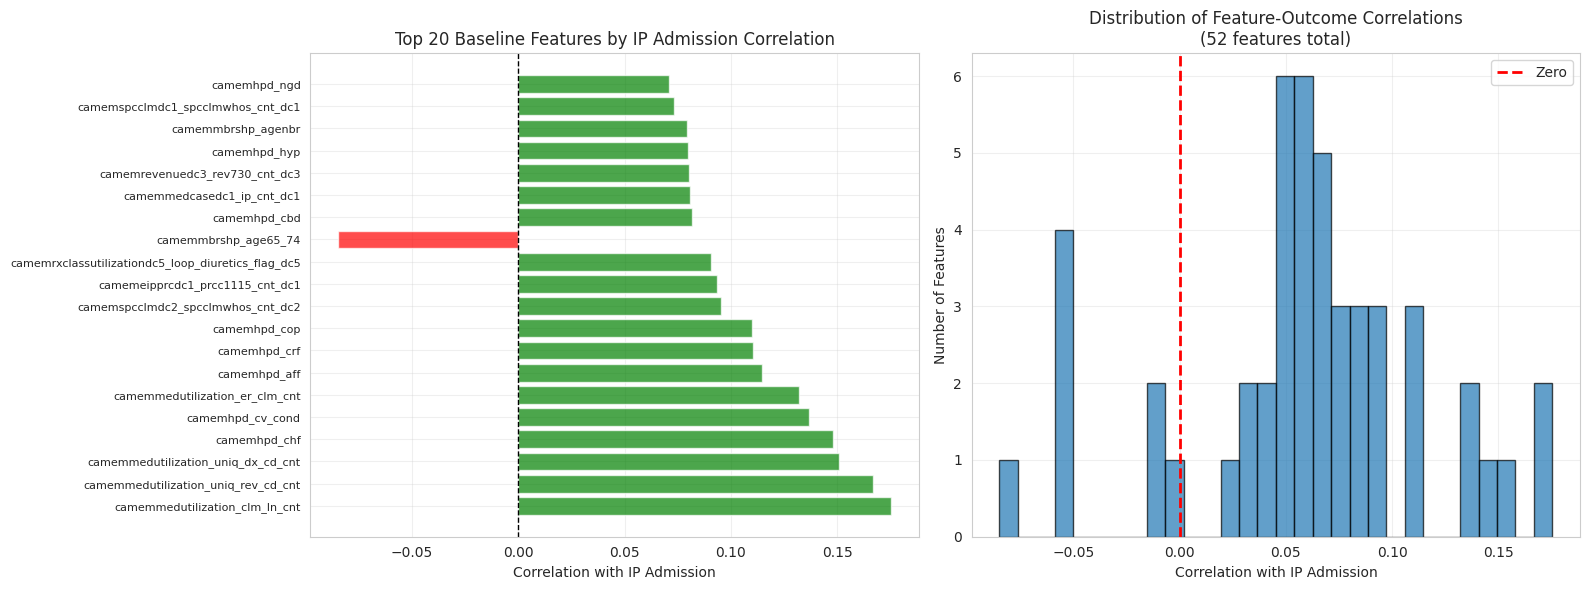


📈 Correlation Summary:
   Max Positive Correlation: 0.1753 (camemmedutilization_clm_ln_cnt)
   Max Negative Correlation: -0.0848
   Mean Absolute Correlation: 0.0728
   Features with |r| > 0.10: 9/52


In [6]:
print(f"🔍 Analyzing correlation between baseline features and {OUTCOME_LABEL}...\n")

# Feature matrix (N x 52)
X_features = df[feature_cols].values
y_outcome = df[OUTCOME_COLUMN].values

# Calculate point-biserial correlation for each baseline feature
correlations = []
for i, col in enumerate(feature_cols):
    corr, pval = stats.pointbiserialr(y_outcome, df[col])
    correlations.append({
        'feature': col,
        'index': i,
        'correlation': corr,
        'abs_correlation': abs(corr),
        'pval': pval
    })

df_corr = pd.DataFrame(correlations).sort_values('abs_correlation', ascending=False)

print(f"📊 Top 20 Most Predictive Baseline Features:")
display(df_corr.head(20))

# Plot top correlations
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
top_20 = df_corr.head(20)
colors = ['red' if x < 0 else 'green' for x in top_20['correlation']]
plt.barh(range(len(top_20)), top_20['correlation'], color=colors, alpha=0.7)
plt.yticks(range(len(top_20)), top_20['feature'], fontsize=8)
plt.xlabel(f'Correlation with {OUTCOME_LABEL}')
plt.title(f'Top 20 Baseline Features by {OUTCOME_LABEL} Correlation')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df_corr['correlation'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel(f'Correlation with {OUTCOME_LABEL}')
plt.ylabel('Number of Features')
plt.title(f'Distribution of Feature-Outcome Correlations\n({len(feature_cols)} features total)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Correlation Summary:")
print(f"   Max Positive Correlation: {df_corr['correlation'].max():.4f} ({df_corr.iloc[0]['feature']})")
print(f"   Max Negative Correlation: {df_corr['correlation'].min():.4f}")
print(f"   Mean Absolute Correlation: {df_corr['abs_correlation'].mean():.4f}")
print(f"   Features with |r| > 0.10: {(df_corr['abs_correlation'] > 0.10).sum()}/{len(feature_cols)}")


### 3.2 Smarter Thresholds: Statistical Significance & Effect Size


🔬 Analyzing correlation thresholds...

📊 Statistical Significance Thresholds:
   Sample size: 2,789,480
   r critical (p < 0.001, Bonferroni): 0.00197
   r critical (p < 0.0001): 0.00233
   → With 2,789,480 samples, almost ANY correlation is 'statistically significant'
   → Statistical significance is NOT a good threshold here!

📏 Effect Size Distribution (Using Multiple Thresholds):
   |r| ≥ 0.01 (  Negligible):  47 / 52 ( 90.4%)
   |r| ≥ 0.02 (  Very Small):  45 / 52 ( 86.5%)
   |r| ≥ 0.05 (       Small):  36 / 52 ( 69.2%)
   |r| ≥ 0.10 (Small-Medium):   9 / 52 ( 17.3%)
   |r| ≥ 0.20 (      Medium):   0 / 52 (  0.0%)
   |r| ≥ 0.30 (       Large):   0 / 52 (  0.0%)
   |r| ≥ 0.50 (  Very Large):   0 / 52 (  0.0%)

📈 Percentile-Based Thresholds:
   Top 50% of features: |r| ≥ 0.0639 (24 features)
   Top 25% of features: |r| ≥ 0.0862 (12 features)
   Top 10% of features: |r| ≥ 0.1335 (5 features)
   Top  5% of features: |r| ≥ 0.1497 (3 features)
   Top  1% of features: |r| ≥ 0.1713 (1 fea

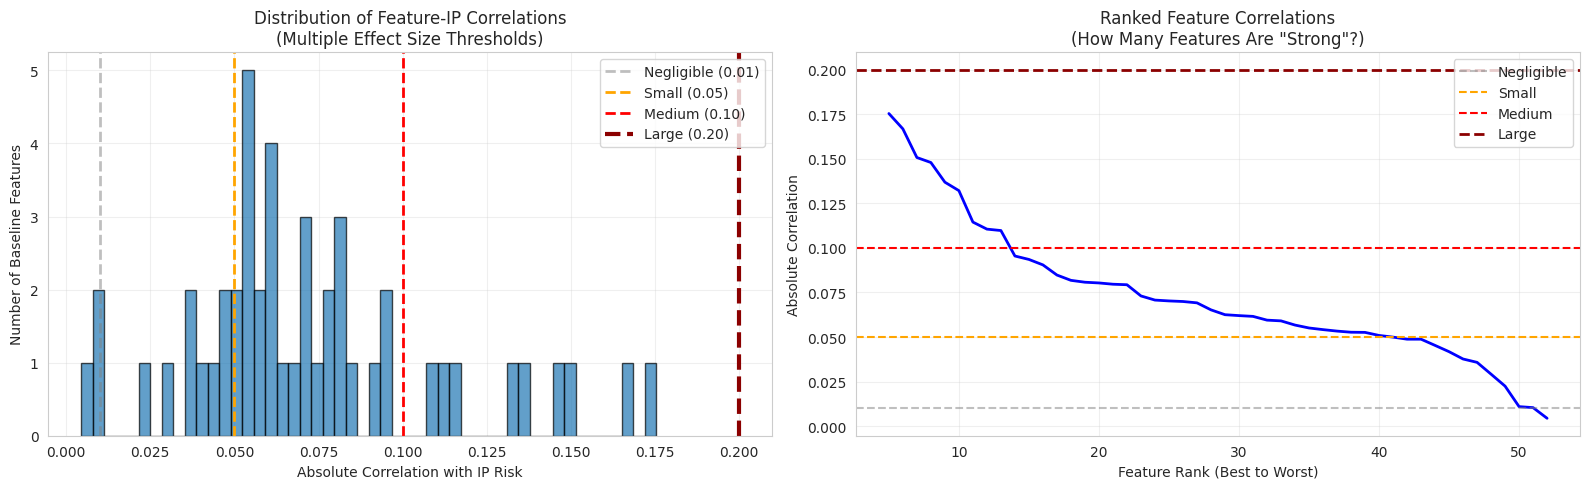


💡 RECOMMENDATIONS:

   For INTERPRETATION:
   - Use |r| ≥ 0.10 as 'meaningfully predictive' → 9 features
   - Use |r| ≥ 0.05 as 'potentially useful' → 36 features

   For FEATURE SELECTION:
   - Top 11 features (top 20%) → r ≥ 0.0935
   - Top 27 features (top 50%) → r ≥ 0.0616

   CONCLUSION:
   - 0.05 is a reasonable 'potentially useful' threshold
   - But 0.10 might be better for 'strongly predictive'
   - Statistical significance (p-value) is meaningless with N=2,789,480


In [7]:
print("🔬 Analyzing correlation thresholds...\n")

# 1. Statistical Significance Threshold
# With large N, even tiny correlations are statistically significant
# Critical r for p < 0.001 with N = 836K: r_critical ≈ 0.011
n_samples = len(df)
n_features = len(feature_cols)
r_critical_001 = 3.29 / np.sqrt(n_samples)  # Bonferroni correction for multiple tests
r_critical_0001 = 3.89 / np.sqrt(n_samples)

print(f"📊 Statistical Significance Thresholds:")
print(f"   Sample size: {n_samples:,}")
print(f"   r critical (p < 0.001, Bonferroni): {r_critical_001:.5f}")
print(f"   r critical (p < 0.0001): {r_critical_0001:.5f}")
print(f"   → With {n_samples:,} samples, almost ANY correlation is 'statistically significant'")
print(f"   → Statistical significance is NOT a good threshold here!")

# 2. Effect Size Interpretation (Cohen's guidelines adapted for correlations)
thresholds = {
    'Negligible': 0.01,
    'Very Small': 0.02,
    'Small': 0.05,
    'Small-Medium': 0.10,
    'Medium': 0.20,
    'Large': 0.30,
    'Very Large': 0.50
}

print(f"\n📏 Effect Size Distribution (Using Multiple Thresholds):")
for label, thresh in thresholds.items():
    count = (df_corr['abs_correlation'] >= thresh).sum()
    pct = count / len(feature_cols) * 100
    print(f"   |r| ≥ {thresh:.2f} ({label:>12}): {count:3d} / {len(feature_cols)} ({pct:5.1f}%)")

# 3. Percentile-based approach
print(f"\n📈 Percentile-Based Thresholds:")
percentiles = [50, 75, 90, 95, 99]
for p in percentiles:
    r_thresh = df_corr['abs_correlation'].quantile(p/100)
    count = (df_corr['abs_correlation'] >= r_thresh).sum()
    print(f"   Top {100-p:2d}% of features: |r| ≥ {r_thresh:.4f} ({count} features)")

# 4. Visual: Histogram with various thresholds
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
counts, bins, patches = ax.hist(df_corr['abs_correlation'], bins=50, alpha=0.7, edgecolor='black')
ax.axvline(x=0.01, color='gray', linestyle='--', linewidth=2, label='Negligible (0.01)', alpha=0.5)
ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=2, label='Small (0.05)')
ax.axvline(x=0.10, color='red', linestyle='--', linewidth=2, label='Medium (0.10)')
ax.axvline(x=0.20, color='darkred', linestyle='--', linewidth=3, label='Large (0.20)')
ax.set_xlabel('Absolute Correlation with IP Risk')
ax.set_ylabel('Number of Baseline Features')
ax.set_title('Distribution of Feature-IP Correlations\n(Multiple Effect Size Thresholds)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
# Cumulative distribution
sorted_corr = np.sort(df_corr['abs_correlation'].values)[::-1]
ax.plot(range(1, len(feature_cols) + 1), sorted_corr, linewidth=2, color='blue')
ax.axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='Negligible')
ax.axhline(y=0.05, color='orange', linestyle='--', label='Small')
ax.axhline(y=0.10, color='red', linestyle='--', label='Medium')
ax.axhline(y=0.20, color='darkred', linestyle='--', linewidth=2, label='Large')
ax.set_xlabel('Feature Rank (Best to Worst)')
ax.set_ylabel('Absolute Correlation')
ax.set_title('Ranked Feature Correlations\n(How Many Features Are "Strong"?)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Recommended thresholds
print(f"\n💡 RECOMMENDATIONS:")
print(f"\n   For INTERPRETATION:")
print(f"   - Use |r| ≥ 0.10 as 'meaningfully predictive' → {(df_corr['abs_correlation'] >= 0.10).sum()} features")
print(f"   - Use |r| ≥ 0.05 as 'potentially useful' → {(df_corr['abs_correlation'] >= 0.05).sum()} features")
print(f"\n   For FEATURE SELECTION:")
# Calculate top percentages based on actual feature count
top_20pct_idx = min(int(len(feature_cols) * 0.2), len(df_corr) - 1)
top_50pct_idx = min(int(len(feature_cols) * 0.5), len(df_corr) - 1)
print(f"   - Top {top_20pct_idx + 1} features (top 20%) → r ≥ {df_corr['abs_correlation'].iloc[top_20pct_idx]:.4f}")
print(f"   - Top {top_50pct_idx + 1} features (top 50%) → r ≥ {df_corr['abs_correlation'].iloc[top_50pct_idx]:.4f}")
print(f"\n   CONCLUSION:")
print(f"   - 0.05 is a reasonable 'potentially useful' threshold")
print(f"   - But 0.10 might be better for 'strongly predictive'")
print(f"   - Statistical significance (p-value) is meaningless with N={n_samples:,}")


### 3.3 Create Balanced Dataset for UMAP (Address 7% Class Imbalance)


In [8]:
print("🎯 Preparing dataset for UMAP visualization...\n")

if BALANCE_CLASSES:
    print("⚠️ CLASS IMBALANCE DETECTED")
    outcome_prevalence = df[OUTCOME_COLUMN].mean()
    print(f"   Outcome prevalence: {outcome_prevalence*100:.1f}%")
    
    if outcome_prevalence < 0.20 or outcome_prevalence > 0.80:
        print(f"   → Highly imbalanced! (Minority class < 20%)")
        print("\n💡 SOLUTION: Downsample majority class to create 50/50 balance.")
        print("   This gives UMAP equal weight to both classes during optimization.\n")
        
        # Separate classes from the full dataset
        df_outcome_pos = df[df[OUTCOME_COLUMN] == 1]
        df_outcome_neg = df[df[OUTCOME_COLUMN] == 0]
        
        print(f"📊 Original IMBALANCED distribution:")
        print(f"   {OUTCOME_LABEL}=1 (minority): {len(df_outcome_pos):,} ({len(df_outcome_pos)/len(df)*100:.2f}%)")
        print(f"   {OUTCOME_LABEL}=0 (majority): {len(df_outcome_neg):,} ({len(df_outcome_neg)/len(df)*100:.2f}%)")
        print(f"   Ratio: 1:{len(df_outcome_neg)/len(df_outcome_pos):.1f} ← Heavily imbalanced!")
        
        # Downsample majority class to match minority count
        print(f"\n⚙️ Downsampling majority class...")
        minority_size = min(len(df_outcome_pos), len(df_outcome_neg))
        df_outcome_pos_balanced = df_outcome_pos.sample(n=minority_size, random_state=UMAP_RANDOM_STATE, replace=False)
        df_outcome_neg_balanced = df_outcome_neg.sample(n=minority_size, random_state=UMAP_RANDOM_STATE, replace=False)
        
        # Combine for balanced dataset
        df_balanced = pd.concat([df_outcome_pos_balanced, df_outcome_neg_balanced]).sample(frac=1, random_state=UMAP_RANDOM_STATE).reset_index(drop=True)
        
        print(f"\n✅ BALANCED dataset created:")
        print(f"   {OUTCOME_LABEL}=1: {(df_balanced[OUTCOME_COLUMN]==1).sum():,} (50.0%)")
        print(f"   {OUTCOME_LABEL}=0: {(df_balanced[OUTCOME_COLUMN]==0).sum():,} (50.0%)")
        print(f"   Total samples: {len(df_balanced):,}")
        print(f"   Ratio: 1:1 ← Perfectly balanced!")
        
        print(f"\n📉 Dataset reduction: {len(df):,} → {len(df_balanced):,} ({len(df_balanced)/len(df)*100:.1f}% of original)")
        print(f"⚡ Speed benefit: UMAP will run faster with fewer samples")
        print(f"🎨 Visual benefit: Both outcome classes equally visible")
        print(f"📊 Clustering benefit: UMAP optimization not biased toward majority class")
    else:
        print("   → Reasonably balanced (minority class >= 20%)")
        print("   → Using full dataset (no downsampling needed)")
        df_balanced = df.copy()
else:
    print("⚙️ Using FULL dataset (balanced sampling disabled)")
    df_balanced = df.copy()

# ⚡ PERFORMANCE CAP: Limit samples for UMAP (prevents 90+ minute runtimes!)
if len(df_balanced) > MAX_UMAP_SAMPLES:
    print(f"\n⚡ PERFORMANCE OPTIMIZATION")
    print(f"   Current size: {len(df_balanced):,} samples (would take 60-120 min!)")
    print(f"   → Downsampling to: {MAX_UMAP_SAMPLES:,} samples")
    print(f"   → Expected UMAP runtime: 3-5 minutes ✅")
    
    # Stratified sampling to maintain outcome distribution
    from sklearn.model_selection import train_test_split
    df_balanced, _ = train_test_split(
        df_balanced, 
        train_size=MAX_UMAP_SAMPLES, 
        stratify=df_balanced[OUTCOME_COLUMN],
        random_state=UMAP_RANDOM_STATE
    )
    print(f"   → Outcome distribution preserved: {df_balanced[OUTCOME_COLUMN].value_counts().to_dict()}")

print(f"\n✅ Ready for UMAP!")
print(f"   Final dataset size: {len(df_balanced):,} samples")
print(f"   Outcome distribution: {df_balanced[OUTCOME_COLUMN].value_counts().to_dict()}")


🎯 Preparing dataset for UMAP visualization...

⚠️ CLASS IMBALANCE DETECTED
   Outcome prevalence: 7.1%
   → Highly imbalanced! (Minority class < 20%)

💡 SOLUTION: Downsample majority class to create 50/50 balance.
   This gives UMAP equal weight to both classes during optimization.

📊 Original IMBALANCED distribution:
   IP Admission=1 (minority): 198,321 (7.11%)
   IP Admission=0 (majority): 2,591,159 (92.89%)
   Ratio: 1:13.1 ← Heavily imbalanced!

⚙️ Downsampling majority class...

✅ BALANCED dataset created:
   IP Admission=1: 198,321 (50.0%)
   IP Admission=0: 198,321 (50.0%)
   Total samples: 396,642
   Ratio: 1:1 ← Perfectly balanced!

📉 Dataset reduction: 2,789,480 → 396,642 (14.2% of original)
⚡ Speed benefit: UMAP will run faster with fewer samples
🎨 Visual benefit: Both outcome classes equally visible
📊 Clustering benefit: UMAP optimization not biased toward majority class

⚡ PERFORMANCE OPTIMIZATION
   Current size: 396,642 samples (would take 60-120 min!)
   → Downsampling

---

## 4. Dimensionality Reduction & Visualization

**What this section does:**
- Uses **UMAP** (Uniform Manifold Approximation and Projection) to project 52D baseline features → 2D
- Creates scatter plots colored by outcome (do high-risk patients cluster together?)
- Generates density heatmaps showing "hot spots" of high risk
- Quantifies cluster separation using **Cohen's D** metric

**Why UMAP?**
- Preserves both local and global structure (better than t-SNE or PCA for large datasets)
- Fast and scalable (can handle 100K+ samples)
- Works well with both embeddings AND handcrafted features
- Tunable parameters to reveal different patterns

**Key Parameters** (configured in Section 0):
- `n_neighbors`: Higher = more global structure (15-200)
- `min_dist`: Lower = tighter clusters (0.0-0.5)


### 4.1 UMAP: 52D → 2D Projection


In [9]:
# This cell has been removed - duplicate of cell in Section 3.3
# Balanced sampling is now handled in Section 3.3

In [10]:
print("🗺️ Running UMAP dimensionality reduction (52D → 2D)...")
print("   This may take a few minutes for large datasets...\n")

# Prepare data for UMAP (use balanced dataset from previous cell)
df_viz = df_balanced.copy()
X_viz_raw = df_viz[feature_cols].values  # Raw baseline features (52D)
y_viz = df_viz[OUTCOME_COLUMN].values

print(f"📊 Dataset for UMAP:")
print(f"   Total samples: {len(df_viz):,}")
print(f"   Features: {len(feature_cols)} baseline features")
print(f"   {OUTCOME_LABEL}=1: {y_viz.sum():,} ({y_viz.mean()*100:.1f}%)")
print(f"   {OUTCOME_LABEL}=0: {(y_viz==0).sum():,} ({(y_viz==0).mean()*100:.1f}%)")

# ⚠️ CRITICAL: Scale features before UMAP!
# Baseline features have different scales (age: 65-90, claims: 0-5000+, flags: 0-1)
# UMAP requires comparable scales, otherwise high-magnitude features dominate
print(f"\n⚙️ Scaling features (StandardScaler)...")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_viz = scaler.fit_transform(X_viz_raw)
print(f"   ✅ Features standardized (mean=0, std=1 per feature)")
print(f"   💡 This ensures all 52 features contribute equally to UMAP")

# Run UMAP with configured parameters
print(f"\n⏳ Running UMAP...")
print(f"   Parameters: n_neighbors={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST}")
print(f"   Estimated time: {len(df_viz)//50000 + 1}-{len(df_viz)//20000 + 2} minutes")

start_time = time.time()
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,  # ✅ Uses configuration from Section 0
    min_dist=UMAP_MIN_DIST,
    metric='euclidean',
    random_state=UMAP_RANDOM_STATE,
    verbose=True
)

embedding_2d = reducer.fit_transform(X_viz)
umap_time = time.time() - start_time

print(f"\n✅ UMAP complete in {umap_time/60:.1f} minutes ({umap_time:.1f} seconds)")
print(f"   2D embedding shape: {embedding_2d.shape}")

# Add UMAP coordinates to dataframe
df_viz['umap_x'] = embedding_2d[:, 0]
df_viz['umap_y'] = embedding_2d[:, 1]

print(f"✅ Ready for visualization!")


🗺️ Running UMAP dimensionality reduction (52D → 2D)...
   This may take a few minutes for large datasets...

📊 Dataset for UMAP:
   Total samples: 120,000
   Features: 52 baseline features
   IP Admission=1: 60,000 (50.0%)
   IP Admission=0: 60,000 (50.0%)

⚙️ Scaling features (StandardScaler)...
   ✅ Features standardized (mean=0, std=1 per feature)
   💡 This ensures all 52 features contribute equally to UMAP

⏳ Running UMAP...
   Parameters: n_neighbors=100, min_dist=0.1
   Estimated time: 3-8 minutes
UMAP(n_jobs=1, n_neighbors=100, random_state=123, verbose=True)
Wed Jan 28 23:33:42 2026 Construct fuzzy simplicial set
Wed Jan 28 23:33:42 2026 Finding Nearest Neighbors
Wed Jan 28 23:33:42 2026 Building RP forest with 22 trees
Wed Jan 28 23:33:51 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Wed Jan 28 23:36:15 2026 Finished Nearest Neighbor Search
Wed Jan 28 23:36:23 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jan 28 23:43:04 2026 Finished embedding

✅ UMAP complete in 9.4 minutes (561.8 seconds)
   2D embedding shape: (120000, 2)
✅ Ready for visualization!


### 4.2 Visualization: 4-Panel Cluster View ⭐

**What you're looking at (2x2 grid):**

| Top-Left | Top-Right |
|----------|-----------|
| **All Points (Gradient)** | **No-Outcome Cases (Blue)** |
| Overall distribution | Where negative cases concentrate |

| Bottom-Left | Bottom-Right |
|-------------|--------------|
| **Outcome Cases (Red)** | **Risk Heatmap** |
| Where positive cases concentrate | Hot zones (red) = high risk regions |

**Why this layout solves overplotting:**
- With 119K+ points, overlaying red+blue creates a visual mess
- **Side-by-side comparison** lets you see EACH class's density pattern separately
- **Key insight**: Compare Top-Right (blue) vs Bottom-Left (red)
  - If they look **different** → good clustering! ✅
  - If they look **identical** → poor separation ❌

**What to look for:**
- Do blue dots cluster in different regions than red dots?
- Does the heatmap show clear red vs green zones?
- Or do both classes have the same density pattern (poor clustering)?


🎨 Creating visualizations...



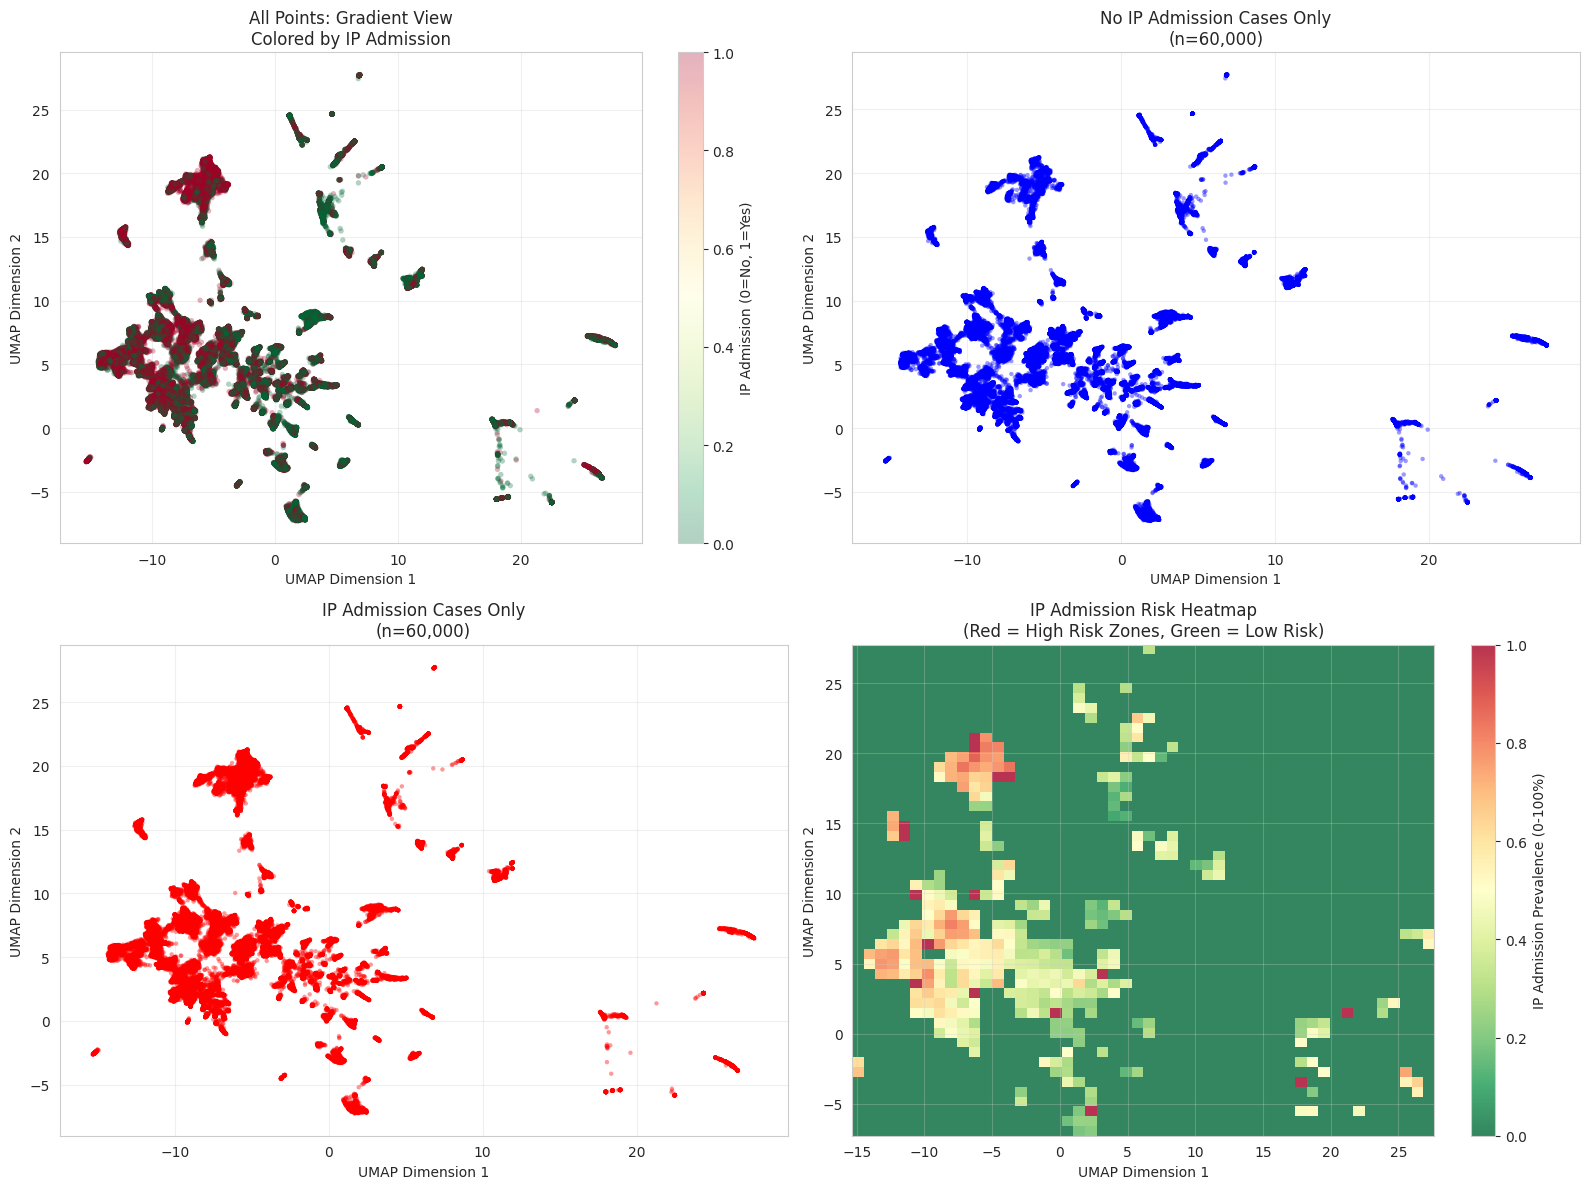

✅ Visualizations complete

💡 How to Interpret the 4-Panel View:

   📊 TOP LEFT (Gradient): Overall distribution of both classes
   📊 TOP RIGHT (Blue): Where No-IP Admission cases cluster
   📊 BOTTOM LEFT (Red): Where IP Admission cases cluster
   📊 BOTTOM RIGHT (Heatmap): Risk 'hot zones' (red) vs 'safe zones' (green)

   ✅ GOOD CLUSTERING: Blue and Red plots show DIFFERENT dense regions
   ❌ POOR CLUSTERING: Blue and Red plots look identical (same dense regions)

   💡 Compare Top-Right vs Bottom-Left:
      - Do they concentrate in DIFFERENT areas? → Embeddings working well!
      - Do they concentrate in the SAME areas? → Limited separation


In [11]:
print("🎨 Creating visualizations...\n")

# 💡 NOTE: Dot sizes adjusted for baseline features
# Baseline features have larger UMAP coordinate space (variance ~73 vs ~5 for embeddings)
# Using larger dots (s=10-15) vs embeddings (s=3-5) for better visibility

# Prepare data splits
df_outcome_neg = df_viz[df_viz[OUTCOME_COLUMN] == 0]
df_outcome_pos = df_viz[df_viz[OUTCOME_COLUMN] == 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All points colored by outcome (continuous gradient)
ax = axes[0, 0]
scatter = ax.scatter(
    df_viz['umap_x'], 
    df_viz['umap_y'],
    c=df_viz[OUTCOME_COLUMN],
    cmap='RdYlGn_r',  # Red = high risk (1), Green = low risk (0)
    alpha=0.3,
    s=15,  # ⬆️ Increased from 5 (baseline features have larger coordinate space)
    edgecolors='none'
)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'All Points: Gradient View\nColored by {OUTCOME_LABEL}')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(f'{OUTCOME_LABEL} (0=No, 1=Yes)')
ax.grid(alpha=0.3)

# Plot 2a: NEGATIVE cases only (side-by-side comparison)
ax = axes[0, 1]
ax.scatter(df_outcome_neg['umap_x'], df_outcome_neg['umap_y'], 
           c='blue', alpha=0.4, s=10, edgecolors='none')  # ⬆️ Increased from s=3
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'No {OUTCOME_LABEL} Cases Only\n(n={len(df_outcome_neg):,})')
ax.grid(alpha=0.3)

# Plot 2b: POSITIVE cases only (side-by-side comparison)
ax = axes[1, 0]
ax.scatter(df_outcome_pos['umap_x'], df_outcome_pos['umap_y'], 
           c='red', alpha=0.4, s=10, edgecolors='none')  # ⬆️ Increased from s=3
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'{OUTCOME_LABEL} Cases Only\n(n={len(df_outcome_pos):,})')
ax.grid(alpha=0.3)

# Plot 4: Density heatmap of outcome prevalence (bottom right)
ax = axes[1, 1]

# Create 2D histogram of outcome prevalence across the embedding space
h, xedges, yedges = np.histogram2d(
    df_viz['umap_x'], 
    df_viz['umap_y'], 
    bins=50
)

h_outcome_pos, _, _ = np.histogram2d(
    df_outcome_pos['umap_x'], 
    df_outcome_pos['umap_y'], 
    bins=[xedges, yedges]
)

# Calculate outcome prevalence per bin
with np.errstate(divide='ignore', invalid='ignore'):
    outcome_prevalence = h_outcome_pos / h
    outcome_prevalence = np.nan_to_num(outcome_prevalence, nan=0)

im = ax.imshow(
    outcome_prevalence.T, 
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='RdYlGn_r',
    aspect='auto',
    alpha=0.8,
    vmin=0,
    vmax=1
)

ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'{OUTCOME_LABEL} Risk Heatmap\n(Red = High Risk Zones, Green = Low Risk)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f'{OUTCOME_LABEL} Prevalence (0-100%)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations complete")
print(f"\n💡 How to Interpret the 4-Panel View:")
print(f"\n   📊 TOP LEFT (Gradient): Overall distribution of both classes")
print(f"   📊 TOP RIGHT (Blue): Where No-{OUTCOME_LABEL} cases cluster")
print(f"   📊 BOTTOM LEFT (Red): Where {OUTCOME_LABEL} cases cluster")
print(f"   📊 BOTTOM RIGHT (Heatmap): Risk 'hot zones' (red) vs 'safe zones' (green)")
print(f"\n   ✅ GOOD CLUSTERING: Blue and Red plots show DIFFERENT dense regions")
print(f"   ❌ POOR CLUSTERING: Blue and Red plots look identical (same dense regions)")
print(f"\n   💡 Compare Top-Right vs Bottom-Left:")
print(f"      - Do they concentrate in DIFFERENT areas? → Embeddings working well!")
print(f"      - Do they concentrate in the SAME areas? → Limited separation")


### 4.3 Quantify Cluster Separation

**What this calculates:**
- **Centroid Distance**: How far apart are the two outcome groups in 2D space?
- **Within-Group Variance**: How spread out is each group?
- **Cohen's D**: Standardized effect size (distance / pooled std deviation)

**Cohen's D Interpretation:**
- **< 0.2**: Negligible separation
- **0.2-0.5**: Small effect
- **0.5-0.8**: Medium effect (noticeable clustering) ✅
- **> 0.8**: Large effect (strong clustering)


In [12]:
print(f"📊 Quantifying cluster separation for {OUTCOME_LABEL}...\n")

# Split by outcome
df_outcome_neg = df_viz[df_viz[OUTCOME_COLUMN] == 0]
df_outcome_pos = df_viz[df_viz[OUTCOME_COLUMN] == 1]

# Calculate centroids (mean position in 2D space)
centroid_neg = df_outcome_neg[['umap_x', 'umap_y']].mean().values
centroid_pos = df_outcome_pos[['umap_x', 'umap_y']].mean().values

centroid_distance = np.linalg.norm(centroid_pos - centroid_neg)

print(f"🎯 Cluster Centroids:")
print(f"   {OUTCOME_LABEL}=0 Centroid: ({centroid_neg[0]:.3f}, {centroid_neg[1]:.3f})")
print(f"   {OUTCOME_LABEL}=1 Centroid: ({centroid_pos[0]:.3f}, {centroid_pos[1]:.3f})")
print(f"   Euclidean Distance: {centroid_distance:.3f}")

# Within-group variance (how spread out is each cluster?)
var_neg = df_outcome_neg[['umap_x', 'umap_y']].var().mean()
var_pos = df_outcome_pos[['umap_x', 'umap_y']].var().mean()

print(f"\n📏 Within-Group Variance:")
print(f"   {OUTCOME_LABEL}=0 Variance: {var_neg:.3f}")
print(f"   {OUTCOME_LABEL}=1 Variance: {var_pos:.3f}")

# Cohen's D effect size (standardized distance between groups)
pooled_std = np.sqrt((var_neg + var_pos) / 2)
cohens_d = centroid_distance / pooled_std

print(f"\n📈 Effect Size (Cohen's D): {cohens_d:.3f}")
if cohens_d < 0.2:
    interpretation = "Negligible (no clustering)"
elif cohens_d < 0.5:
    interpretation = "Small effect"
elif cohens_d < 0.8:
    interpretation = "Medium effect (noticeable separation)"
else:
    interpretation = "Large effect (strong clustering)"
print(f"   Interpretation: {interpretation}")

print(f"\n💡 What this means:")
if cohens_d >= 0.5:
    print(f"   ✅ Baseline features meaningfully separate {OUTCOME_LABEL} groups!")
    print(f"   ✅ Traditional features capture clinical patterns relevant to {OUTCOME_LABEL}")
    print(f"   ✅ Good foundation for predictive models")
else:
    print(f"   ⚠️ Limited separation between {OUTCOME_LABEL} groups")
    print(f"   ⚠️ Baseline features may not strongly capture this specific outcome")
    print(f"   ⚠️ May benefit from additional features (e.g., embeddings)")


📊 Quantifying cluster separation for IP Admission...

🎯 Cluster Centroids:
   IP Admission=0 Centroid: (-2.782, 6.260)
   IP Admission=1 Centroid: (-5.625, 8.248)
   Euclidean Distance: 3.469

📏 Within-Group Variance:
   IP Admission=0 Variance: 47.342
   IP Admission=1 Variance: 45.830

📈 Effect Size (Cohen's D): 0.508
   Interpretation: Medium effect (noticeable separation)

💡 What this means:
   ✅ Baseline features meaningfully separate IP Admission groups!
   ✅ Traditional features capture clinical patterns relevant to IP Admission
   ✅ Good foundation for predictive models


---

## 5. 📊 Summary: Key Findings

**This is your main takeaway section!**  
Review this after running the analysis to understand if your baseline features cluster well by outcome.


In [13]:
print("="*80)
print(f"🎯 KEY FINDINGS: Do Baseline Features Cluster by {OUTCOME_LABEL}?")
print("="*80)

print(f"\n1️⃣ CLUSTER SEPARATION (UMAP 2D):")
print(f"   - Feature Set: {FEATURE_NAME}")
print(f"   - Number of Features: {len(feature_cols)}")
print(f"   - Centroid Distance: {centroid_distance:.3f}")
print(f"   - Cohen's D Effect Size: {cohens_d:.3f} ({interpretation})")
print(f"   - Interpretation: {'✅ Baseline features separate outcome groups well' if cohens_d > 0.5 else '⚠️ Limited separation' if cohens_d > 0.3 else '❌ Minimal/no separation'}")

print(f"\n2️⃣ PREDICTIVE BASELINE FEATURES:")
top_feat = df_corr.iloc[0]
print(f"   - Most Predictive: {top_feat['feature']} (r={top_feat['correlation']:.4f})")
print(f"   - Mean Abs Correlation: {df_corr['abs_correlation'].mean():.4f}")
print(f"   - Strong Predictors (|r| > {CORRELATION_THRESHOLD}): {(df_corr['abs_correlation'] > CORRELATION_THRESHOLD).sum()} / {len(feature_cols)} features")
print(f"   - Very Strong Predictors (|r| > 0.10): {(df_corr['abs_correlation'] > 0.10).sum()} / {len(feature_cols)} features")

print(f"\n3️⃣ BUSINESS IMPLICATIONS:")
if cohens_d >= 0.8:
    print(f"   ✅✅ Baseline features are EXCEPTIONALLY VALUABLE for {OUTCOME_LABEL} prediction")
    print(f"   ✅ Very clear visual separation between outcome groups")
    print(f"   ✅ Traditional features capture strong risk patterns")
    print(f"   ✅ Strong foundation for predictive modeling")
elif cohens_d >= 0.5:
    print(f"   ✅ Baseline features are HIGHLY VALUABLE for {OUTCOME_LABEL} prediction")
    print(f"   ✅ Clear visual separation between outcome groups")
    print(f"   ✅ Traditional feature engineering is effective")
    print(f"   ✅ Good candidate for hybrid model (with embeddings)")
elif cohens_d >= 0.3:
    print(f"   ⚠️ Baseline features provide MODERATE value for {OUTCOME_LABEL} prediction")
    print(f"   ⚠️ Some visual separation, but not dramatic")
    print(f"   ⚠️ May benefit from additional features (e.g., embeddings)")
    print(f"   ⚠️ Room for improvement with advanced features")
else:
    print(f"   ❌ Baseline features show LIMITED clustering by {OUTCOME_LABEL}")
    print(f"   ❌ Minimal visual separation between outcome groups")
    print(f"   ❌ Traditional features may miss key patterns")
    print(f"   ❌ Consider: (1) Additional features? (2) Embeddings may add value")

print(f"\n4️⃣ NEXT STEPS:")
print(f"   📊 Review the visualizations in Section 4.2 above")
print(f"   📊 Check the density heatmap - are there 'hot spots' of {OUTCOME_LABEL}?")
print(f"   📊 Train a predictive model with embeddings to quantify actual performance lift")
print(f"\n{'='*80}")


🎯 KEY FINDINGS: Do Baseline Features Cluster by IP Admission?

1️⃣ CLUSTER SEPARATION (UMAP 2D):
   - Feature Set: baseline_features
   - Number of Features: 52
   - Centroid Distance: 3.469
   - Cohen's D Effect Size: 0.508 (Medium effect (noticeable separation))
   - Interpretation: ✅ Baseline features separate outcome groups well

2️⃣ PREDICTIVE BASELINE FEATURES:
   - Most Predictive: camemmedutilization_clm_ln_cnt (r=0.1753)
   - Mean Abs Correlation: 0.0728
   - Strong Predictors (|r| > 0.05): 36 / 52 features
   - Very Strong Predictors (|r| > 0.10): 9 / 52 features

3️⃣ BUSINESS IMPLICATIONS:
   ✅ Baseline features are HIGHLY VALUABLE for IP Admission prediction
   ✅ Clear visual separation between outcome groups
   ✅ Traditional feature engineering is effective
   ✅ Good candidate for hybrid model (with embeddings)

4️⃣ NEXT STEPS:
   📊 Review the visualizations in Section 4.2 above
   📊 Check the density heatmap - are there 'hot spots' of IP Admission?
   📊 Train a predictive